Data loaded. First 5 rows:
   FlightNumber        Date BoosterVersion  PayloadMass Orbit    LaunchSite  \
0             1  2010-06-04       Falcon 9  6104.959412   LEO  CCAFS SLC 40   
1             2  2012-05-22       Falcon 9   525.000000   LEO  CCAFS SLC 40   
2             3  2013-03-01       Falcon 9   677.000000   ISS  CCAFS SLC 40   
3             4  2013-09-29       Falcon 9   500.000000    PO   VAFB SLC 4E   
4             5  2013-12-03       Falcon 9  3170.000000   GTO  CCAFS SLC 40   

       Outcome  Flights  GridFins  Reused   Legs LandingPad  Block  \
0    None None        1     False   False  False        NaN    1.0   
1    None None        1     False   False  False        NaN    1.0   
2    None None        1     False   False  False        NaN    1.0   
3  False Ocean        1     False   False  False        NaN    1.0   
4    None None        1     False   False  False        NaN    1.0   

   ReusedCount Serial   Longitude   Latitude  Class  
0            0  B0003  

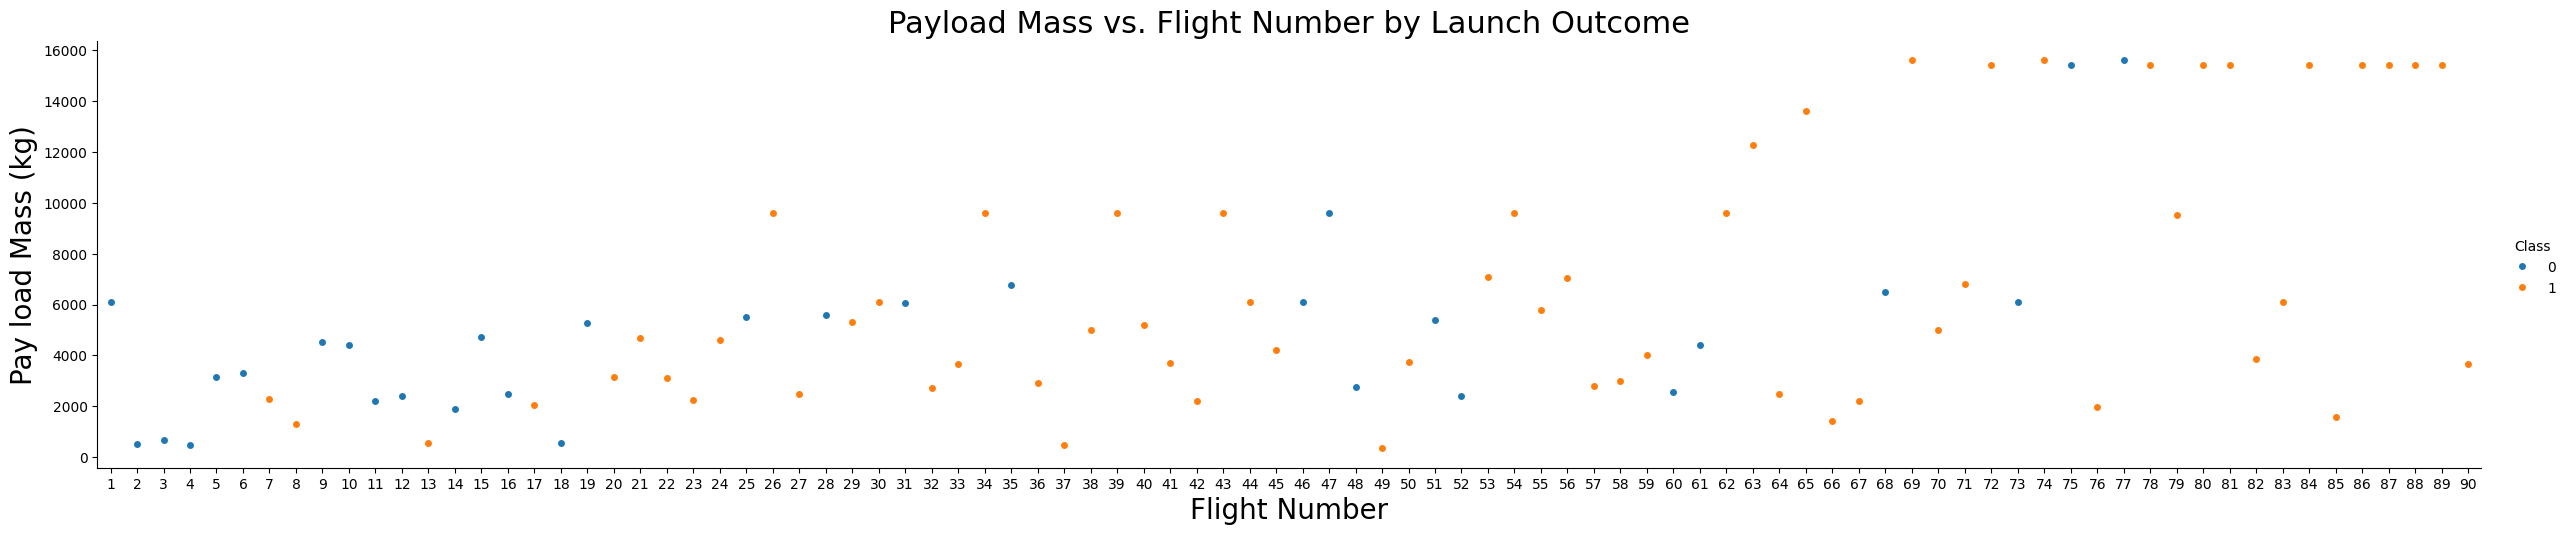

Plot 1 generated.

Generating Plot 2 (TASK 1): LaunchSite vs. FlightNumber


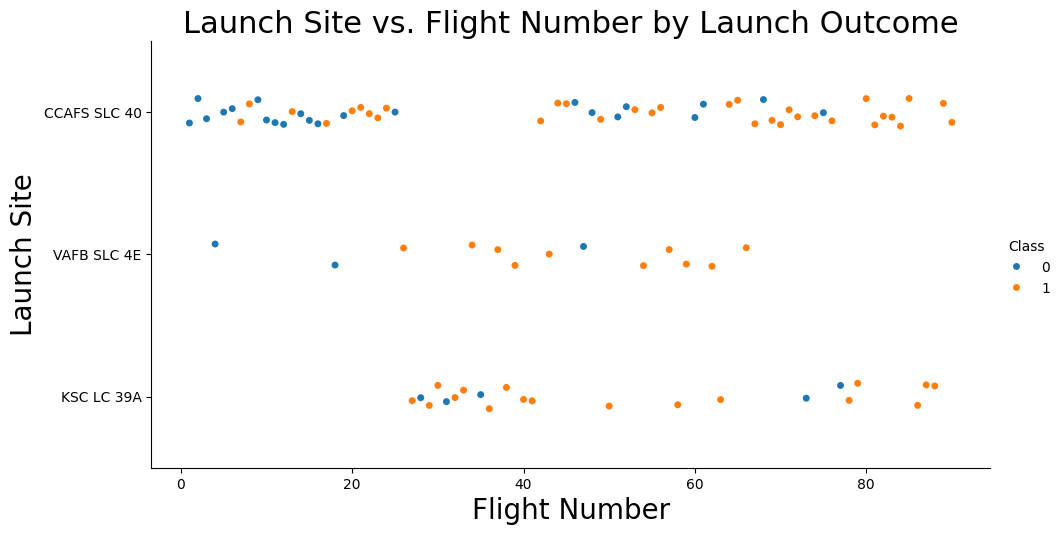

Plot 2 generated.

Generating Plot 3 (TASK 2): LaunchSite vs. PayloadMass


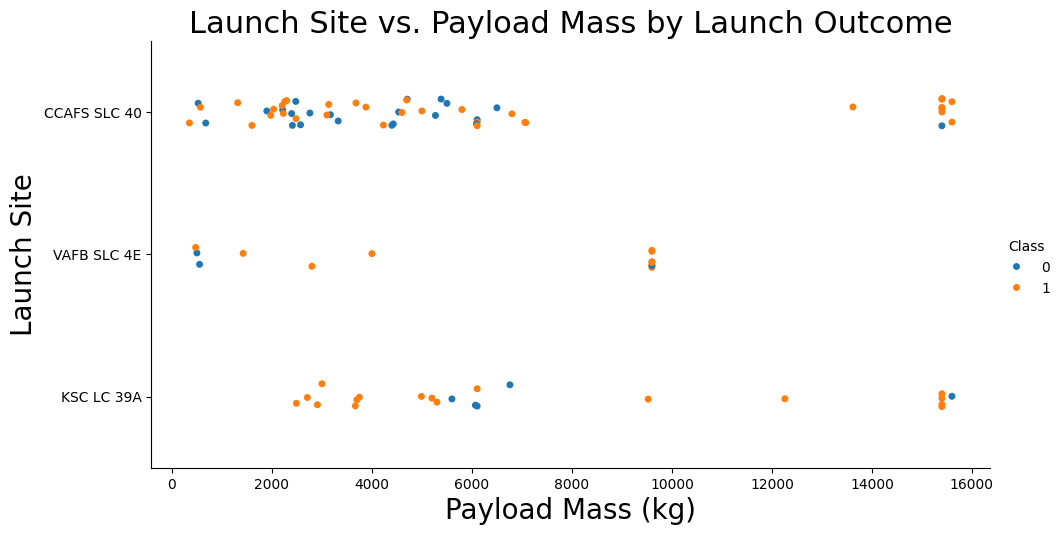

Plot 3 generated.

Generating Plot 4 (TASK 3): Success Rate by Orbit Type


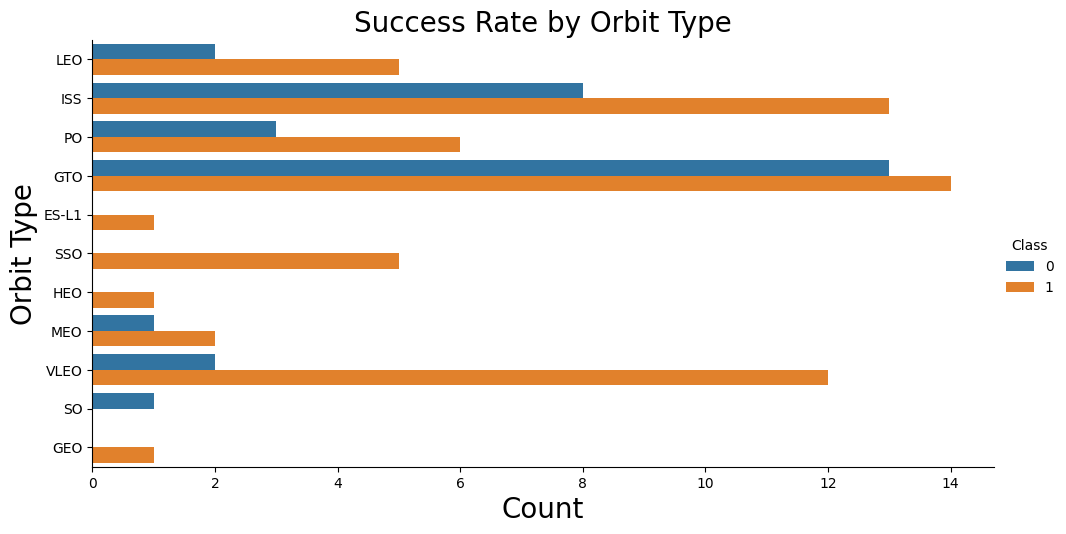

Plot 4 generated.

Generating Plot 5 (TASK 4): Orbit vs. PayloadMass


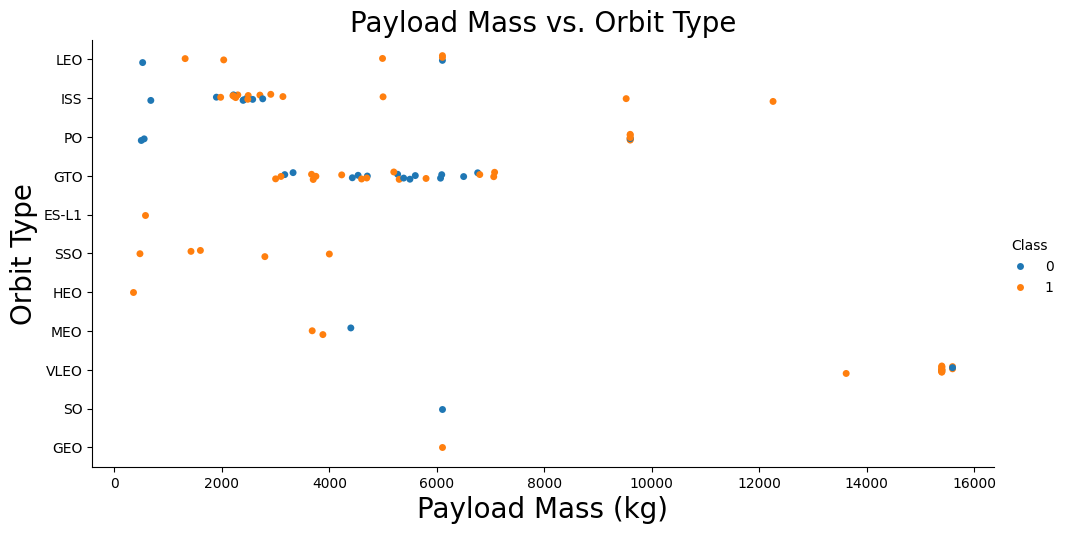

Plot 5 generated.

Generating Plot 6 (TASK 5): Block vs. FlightNumber


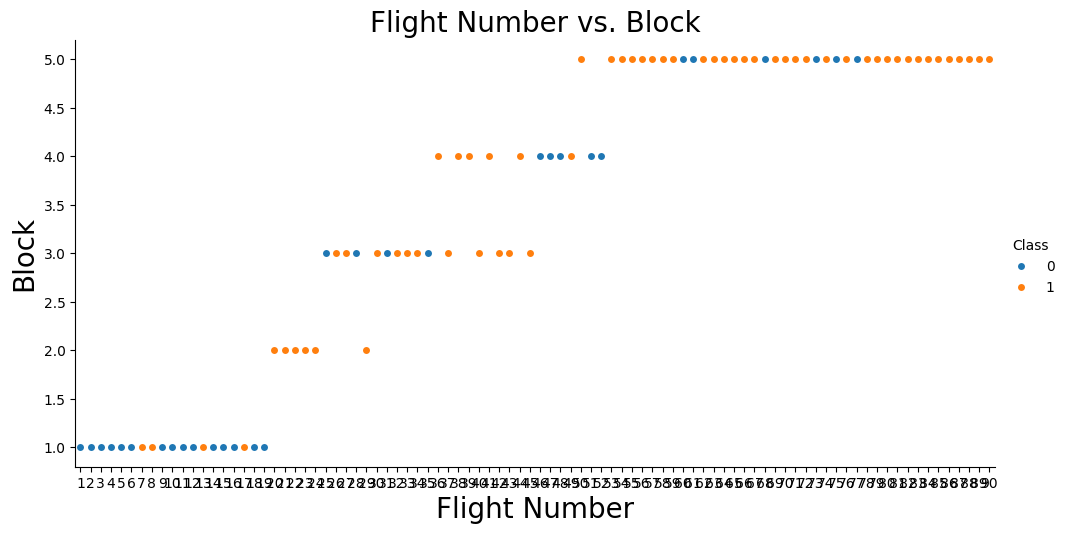

Plot 6 generated.

Extracting year from Date column...
Year column created.

Generating Plot 7 (TASK 6): SpaceX Launch Success Rate by Year


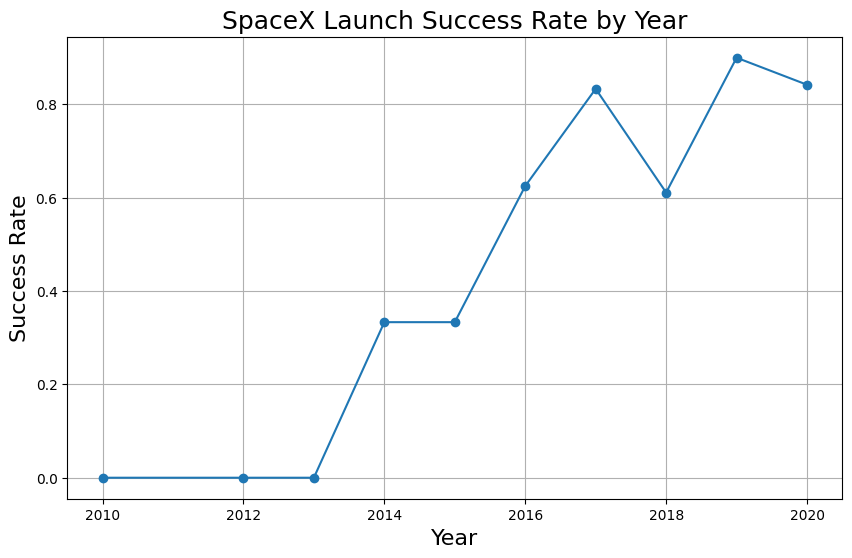

Plot 7 generated.

Starting Feature Engineering...
Features selected. First 5 rows of features:
   FlightNumber  PayloadMass Orbit    LaunchSite  Flights  GridFins  Reused  \
0             1  6104.959412   LEO  CCAFS SLC 40        1     False   False   
1             2   525.000000   LEO  CCAFS SLC 40        1     False   False   
2             3   677.000000   ISS  CCAFS SLC 40        1     False   False   
3             4   500.000000    PO   VAFB SLC 4E        1     False   False   
4             5  3170.000000   GTO  CCAFS SLC 40        1     False   False   

    Legs LandingPad  Block  ReusedCount Serial  
0  False        NaN    1.0            0  B0003  
1  False        NaN    1.0            0  B0005  
2  False        NaN    1.0            0  B0007  
3  False        NaN    1.0            0  B1003  
4  False        NaN    1.0            0  B1004  


Applying one-hot encoding (TASK 7)...
One-hot encoding complete. First 5 rows of new dataframe:
   FlightNumber  PayloadMass  Flights

In [1]:
# SpaceX Falcon 9 First Stage Landing Prediction
#
# ## Assignment: Exploring and Preparing Data
#
# Estimated time needed: 70 minutes
#
# In this assignment, we will predict if the Falcon 9 first stage will land successfully. SpaceX advertises Falcon 9 rocket launches on its website with a cost of 62 million dollars; other providers cost upward of 165 million dollars each, much of the savings is due to the fact that SpaceX can
# reuse the first stage.
#
# In this lab, you will perform Exploratory Data Analysis and Feature Engineering.
#
# ### Objectives
#
# Perform exploratory Data Analysis and Feature Engineering using Pandas and Matplotlib
#
# * Exploratory Data Analysis
# * Preparing Data Feature Engineering
#
# ## Import Libraries and Define Auxiliary Functions
#
# We will import the following libraries for the lab
#
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ## Exploratory Data Analysis
#
# First, let's read the SpaceX dataset into a Pandas dataframe and print its summary
#
# Note: The original notebook used a pyodide-specific method to fetch data.
# We will use the standard pandas `read_csv` method to load the data from the URL.

URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
df = pd.read_csv(URL)

print("Data loaded. First 5 rows:")
print(df.head(5))
print("\n")

# First, let's try to see how the FlightNumber (indicating the continuous launch attempts.) and Payload variables would affect the launch outcome.
# We can plot out the FlightNumber vs. PayloadMass and overlay the outcome of the launch. We see that as the flight number increases, the first stage is more likely to land successfully. The payload mass also appears to be a factor; even with more massive payloads, the first stage
# often returns successfully.

print("Generating Plot 1: PayloadMass vs. FlightNumber")
sns.catplot(y="PayloadMass", x="FlightNumber", hue="Class", data=df, aspect=5)
plt.xlabel("Flight Number", fontsize=20)
plt.ylabel("Pay load Mass (kg)", fontsize=20)
plt.title("Payload Mass vs. Flight Number by Launch Outcome", fontsize=22)
plt.show()
print("Plot 1 generated.\n")


# Next, let's drill down to each site visualize its detailed launch records.
#
# ### TASK 1: Visualize the relationship between Flight Number and Launch Site
#
# Use the function catplot to plot FlightNumber vs LaunchSite, set the parameter x parameter to FlightNumber, set the y to Launch Site and set the parameter hue to 'class'

print("Generating Plot 2 (TASK 1): LaunchSite vs. FlightNumber")
# Plot a scatter point chart with x axis to be Flight Number and y axis to be the launch site, and hue to be the class value
sns.catplot(y="LaunchSite", x="FlightNumber", hue="Class", data=df, aspect=2)
plt.xlabel("Flight Number", fontsize=20)
plt.ylabel("Launch Site", fontsize=20)
plt.title("Launch Site vs. Flight Number by Launch Outcome", fontsize=22)
plt.show()
print("Plot 2 generated.\n")

# Now try to explain the patterns you found in the Flight Number vs. Launch Site scatter point plots.
#
# ### TASK 2: Visualize the relationship between Payload Mass and Launch Site
#
# We also want to observe if there is any relationship between launch sites and their payload mass.

print("Generating Plot 3 (TASK 2): LaunchSite vs. PayloadMass")
# Plot a scatter point chart with x axis to be Payload Mass (kg) and y axis to be the launch site, and hue to be the class value
sns.catplot(y="LaunchSite", x="PayloadMass", hue="Class", data=df, aspect=2)
plt.xlabel("Payload Mass (kg)", fontsize=20)
plt.ylabel("Launch Site", fontsize=20)
plt.title("Launch Site vs. Payload Mass by Launch Outcome", fontsize=22)
plt.show()
print("Plot 3 generated.\n")

# Now if you observe Payload Mass Vs. Launch Site scatter point chart you will find for the VAFB-SLC launchsite there are no rockets launched for heavypayload mass(greater than 10000).
#
# ### TASK 3: Visualize the relationship between success rate of each orbit type
#
# Next, we want to visually check if there are any relationship between success rate and orbit type.
#
# Let's create a bar chart for the sucess rate of each orbit

print("Generating Plot 4 (TASK 3): Success Rate by Orbit Type")
# Plot the success rate for each orbit type
sns.catplot(y="Orbit", hue="Class", data=df, kind="count", aspect=2)
plt.xlabel("Count", fontsize=20)
plt.ylabel("Orbit Type", fontsize=20)
plt.title("Success Rate by Orbit Type", fontsize=20)
plt.show()
print("Plot 4 generated.\n")

# Analyze the plotted bar chart to identify which orbits have the highest success rates.
#
# ### TASK 4: Visualize the relationship between FlightNumber and Orbit type
#
# For each orbit, we want to see if there is any relationship between FlightNumber and Orbit type.
# Note: The notebook title says FlightNumber, but the code plots PayloadMass. We follow the code.

print("Generating Plot 5 (TASK 4): Orbit vs. PayloadMass")
# Plot scatter point chart with x axis to be PayloadMass (kg) and y axis to be orbit, and hue to be the class value
sns.catplot(y="Orbit", x="PayloadMass", hue="Class", data=df, aspect=2)
plt.xlabel("Payload Mass (kg)", fontsize=20)
plt.ylabel("Orbit Type", fontsize=20)
plt.title("Payload Mass vs. Orbit Type", fontsize=20)
plt.show()
print("Plot 5 generated.\n")

# You can observe that in the LEO orbit, success seems to be related to the number of flights. Conversely, in the GTO orbit, there appears to be no relationship between flight number and success.
#
# ### TASK 5: Visualize the relationship between Payload Mass and Orbit type
#
# Similarly, we can plot the Payload Mass vs. Orbit scatter point charts to reveal the relationship between Payload Mass and Orbit type
# Note: The notebook title says Payload Mass and Orbit, but the code plots Block and FlightNumber. We follow the code.

print("Generating Plot 6 (TASK 5): Block vs. FlightNumber")
# Plot scatter point chart with x axis to be Flight Number and y axis to be Block, and hue to be the class value
sns.catplot(y="Block", x="FlightNumber", hue="Class", data=df, aspect=2)
plt.xlabel("Flight Number", fontsize=20)
plt.ylabel("Block", fontsize=20)
plt.title("Flight Number vs. Block", fontsize=20)
plt.show()
print("Plot 6 generated.\n")


# With heavy payloads the successful landing or positive landing rate are more for Polar, LEO and ISS.
# However, for GTO, it's difficult to distinguish between successful and unsuccessful landings as both outcomes are present.
#
# ### TASK 6: Visualize the launch success yearly trend
#
# You can plot a line chart with x axis to be Year and y axis to be average success rate, to get the average launch success trend.
#
# The function will help you get the year from the date:

# A function to Extract years from the date
# Note: The original notebook's method was imperative and overwrote the 'Date' column.
# This version creates a new 'Year' column, which is better practice and matches the
# comment in the subsequent cell.
print("Extracting year from Date column...")
df['Year'] = pd.to_datetime(df['Date']).dt.year
print("Year column created.\n")


print("Generating Plot 7 (TASK 6): SpaceX Launch Success Rate by Year")
# Calculate yearly success rate
yearly_success = df.groupby('Year')['Class'].mean()

# Plot the line chart of yearly success rate
plt.figure(figsize=(10, 6))
plt.plot(yearly_success.index, yearly_success.values, marker='o') # Corrected marker from '0' to 'o'
plt.xlabel("Year", fontsize=16)
plt.ylabel("Success Rate", fontsize=16)
plt.title("SpaceX Launch Success Rate by Year", fontsize=18)
plt.grid(True)
plt.show()
print("Plot 7 generated.\n")

# you can observe that the sucess rate since 2013 kept increasing till 2020
#
# ## Features Engineering
#
# By now, you should obtain some preliminary insights about how each important variable would affect the success rate, we will select the features that will be used in success prediction in the future module.

print("Starting Feature Engineering...")
features = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial']]
print("Features selected. First 5 rows of features:")
print(features.head())
print("\n")

#
# ### TASK 7: Create dummy variables to categorical columns
#
# Use the function get_dummies and features dataframe to apply OneHotEncoder to the column Orbits, LaunchSite, LandingPad, and Serial. Assign the value to the variable features_one_hot, display the results using the method head. Your result dataframe must
# include all features including the encoded ones.

print("Applying one-hot encoding (TASK 7)...")
# Create dummy variables (one-hot encoding) for categorical columns
features_one_hot = pd.get_dummies(features, columns=['Orbit', 'LaunchSite', 'LandingPad', 'Serial'])
print("One-hot encoding complete. First 5 rows of new dataframe:")
print(features_one_hot.head())
print(f"New dataframe shape: {features_one_hot.shape}\n")


#
# ### TASK 8: Cast all numeric columns to float64
#
# Now that our features_one_hot dataframe only contains numbers, cast the entire dataframe to variable type float64

print("Casting all columns to float64 (TASK 8)...")
# Convert all columns in features_one_hot to float64
features_one_hot = features_one_hot.astype('float64')
print("Casting complete.")
print("Data types of new dataframe:")
print(features_one_hot.dtypes)
print("\n")


# We can now export it to a CSV for the next section, but to make the answers consistent, in the next lab we will provide data in a pre-selected date range.

print("Exporting to CSV...")
features_one_hot.to_csv('dataset_part_3.csv', index=False)
print("Export complete: 'dataset_part_3.csv'")
print("\nAll tasks replicated.")

#
# ### Authors
#
# [Pratiksha Verma](https://www.linkedin.com/in/pratiksha-verma-6487561b1/)
#